In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Part 1: Loading the Dataset; Preliminary Analysis

In this part, we will load the data into a DataFrame, and explore the structure of the dataset.

In [2]:
diamonds = pd.read_csv('diamonds.txt', delimiter='\t')
diamonds.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


We will determine the size of the dataset. It will gives the number of rows and columns. 

In [3]:
diamonds.shape

(53940, 10)

We will now inspect the distribution of the columns in the dataset. The `describe()` method provides an overview of the central tendency, dispersion, and shape of the dataset’s distribution, excluding NaN values.


In [4]:
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## Part 2: Filtering and Sorting

We will start by viewing information about the 5 most expensive diamonds in the dataset.


In [5]:
expensive_diamonds = diamonds[['price','carat', 'cut', 'color', 'clarity']]
expensive_diamonds.sort_values(by='price', ascending=False)
expensive_diamonds.head(5)

,price,carat,cut,color,clarity
1,326,0.23,Ideal,E,SI2
2,326,0.21,Premium,E,SI1
3,327,0.23,Good,E,VS1
4,334,0.29,Premium,I,VS2
5,335,0.31,Good,J,SI2


We will start by viewing information about the 5 least expensive diamonds in the dataset.


In [6]:
least_expensive_diamonds = diamonds[['price','carat', 'cut', 'color', 'clarity']]
least_expensive_diamonds.sort_values(by='price', ascending=True)
least_expensive_diamonds.head(5)


,price,carat,cut,color,clarity
1,326,0.23,Ideal,E,SI2
2,326,0.21,Premium,E,SI1
3,327,0.23,Good,E,VS1
4,334,0.29,Premium,I,VS2
5,335,0.31,Good,J,SI2


We will now filter the dataset for diamonds with an ideal cut and sort by carat size to view the 5 largest diamonds.


In [7]:
largest_ideal_diamonds = diamonds[['price', 'carat', 'cut', 'color', 'clarity']][diamonds['cut'] == 'Ideal']
largest_ideal_diamonds.sort_values(by='carat', ascending=False)
largest_ideal_diamonds.head(5)


,price,carat,cut,color,clarity
1,326,0.23,Ideal,E,SI2
12,340,0.23,Ideal,J,VS1
14,344,0.31,Ideal,J,SI2
17,348,0.30,Ideal,I,SI2
40,403,0.33,Ideal,I,SI2


We will view information about the largest diamonds with a fair cut.


In [8]:
largest_fair_diamonds = diamonds[['price', 'carat', 'cut', 'color', 'clarity']][diamonds['cut'] == 'Fair']
largest_fair_diamonds.sort_values(by='carat', ascending=False)
largest_fair_diamonds.head(5)

,price,carat,cut,color,clarity
9,337,0.22,Fair,E,VS2
92,2757,0.86,Fair,E,SI2
98,2759,0.96,Fair,F,SI2
124,2762,0.70,Fair,F,VS2
125,2762,0.70,Fair,F,VS2


## Part 3: Working with Categorical Variables

In this part, we will create lists to define the correct order for each of the three categorical variables: cut, color, and clarity.

In [9]:
clarity_levels = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
cut_levels = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_levels = ['J', 'I', 'H', 'G', 'F', 'E', 'D']


We will communicate the correct order of the levels for the cut, color, and clarity columns using the pd.Categorical() function. 

In [10]:
diamonds['clarity'] = pd.Categorical(diamonds['clarity'], categories=clarity_levels, ordered=True)
diamonds['cut'] = pd.Categorical(diamonds['cut'], categories=cut_levels, ordered=True)
diamonds['color'] = pd.Categorical(diamonds['color'], categories=color_levels, ordered=True)


We will  create lists of named colors to serve as palettes for visualizations.

In [11]:
clarity_pal = ['#D3D3D3', '#A9A9A9', '#808080', '#696969', '#505050', '#303030', '#101010', '#000000']
cut_pal = ['#FFD700', '#C0C0C0', '#B0E0E6', '#FFB6C1', '#FF69B4']
color_pal = ['#FFDDC1', '#FFE4C4', '#FFDAB9', '#FFB6C1', '#FFA07A', '#FA8072', '#FF6347']


## Part 4: Displaying Counts for Categorical Variables

In this part, we will determine the number of diamonds for each level of the three categorical variables: cut, color, and clarity. We will begin by counting the number of diamonds for each level of the cut variable.

In [12]:
diamonds['cut'].value_counts().sort_index()


cut
Fair          1610
Good          4906
Very Good    12082
Premium      13791
Ideal        21551
Name: count, dtype: int64

 We will count the number of diamonds for each level of the color variable.

In [13]:
diamonds['color'].value_counts().sort_index()

color
J     2808
I     5422
H     8304
G    11292
F     9542
E     9797
D     6775
Name: count, dtype: int64

We will count the number of diamonds for each level of the clarity variable.

In [14]:
diamonds['clarity'].value_counts().sort_index()


clarity
I1        741
SI2      9194
SI1     13065
VS2     12258
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
Name: count, dtype: int64

## Part 5: Scatterplots of Price Against Carat

In this part, we will explore the relationship between the price and carat attributes by generating scatter plots. 

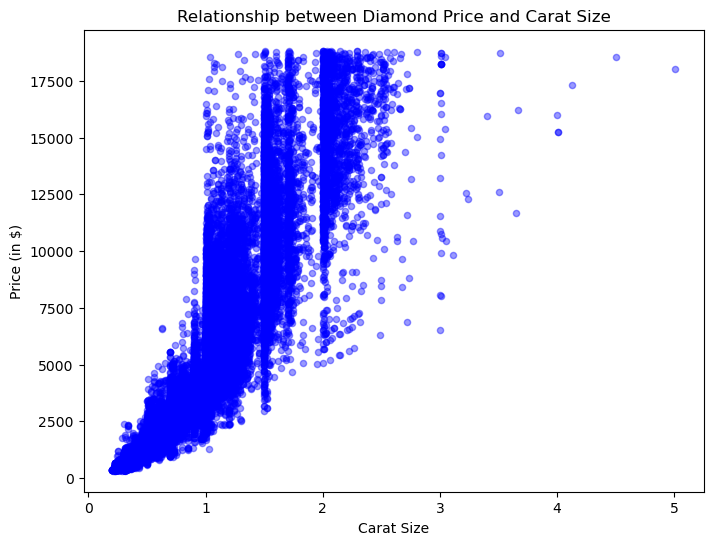

In [15]:
plt.figure(figsize=[8,6])
plt.scatter(diamonds['carat'], diamonds['price'], s=20, c='blue', alpha=0.4)
plt.xlabel('Carat Size')
plt.ylabel('Price (in $)')
plt.title('Relationship between Diamond Price and Carat Size')
plt.show()

Reproducing the plot but coloring points by clarity level

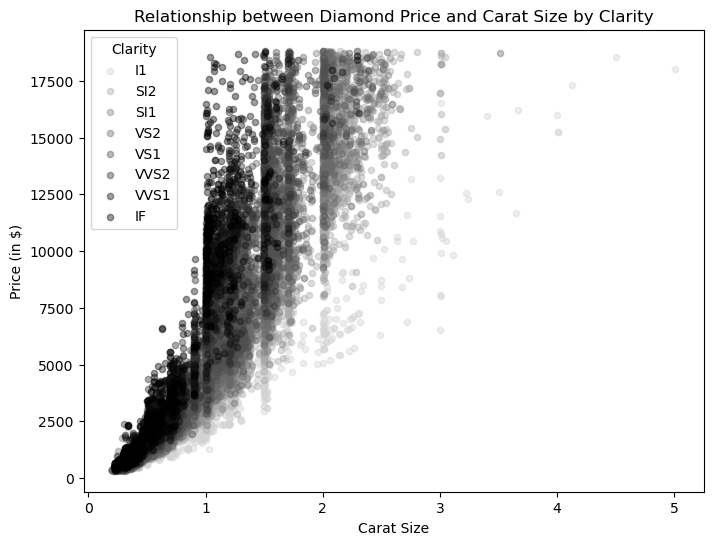

In [16]:
plt.figure(figsize=[8,6])
for clarity, color in zip(clarity_levels, clarity_pal):
    subset = diamonds[diamonds['clarity'] == clarity]
    plt.scatter(subset['carat'], subset['price'], s=20, c=color, alpha=0.4, label=clarity)

plt.xlabel('Carat Size')
plt.ylabel('Price (in $)')
plt.title('Relationship between Diamond Price and Carat Size by Clarity')
plt.legend(title='Clarity')
plt.show()

Creating subplots for each clarity level

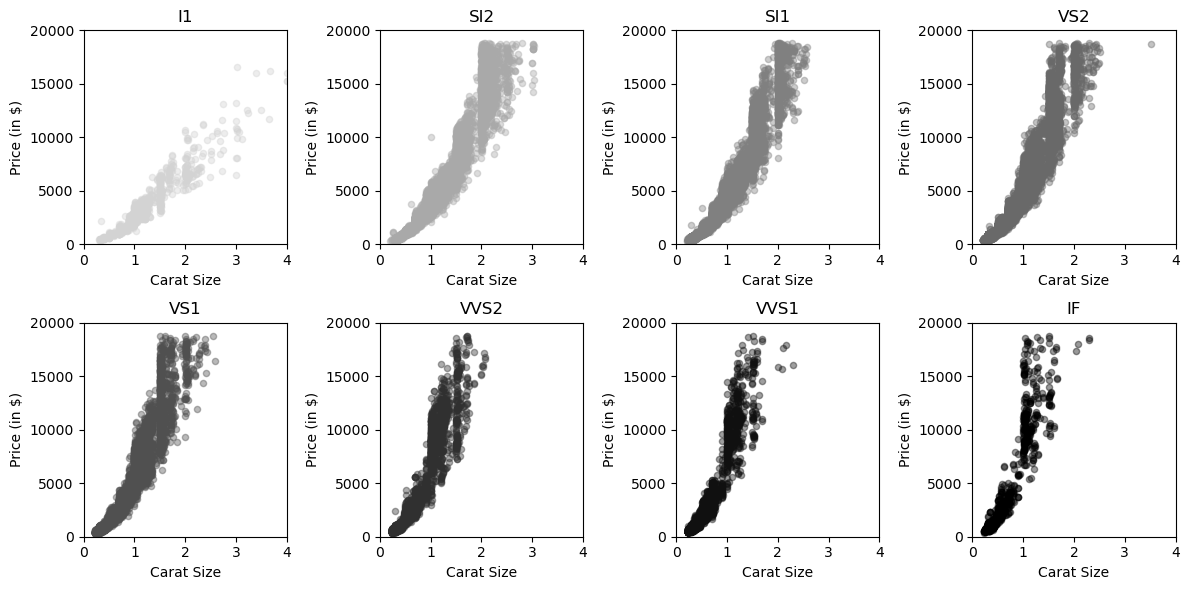

In [17]:
fig, axes = plt.subplots(2, 4, figsize=[12,6])
axes = axes.flatten()
for ax, clarity, color in zip(axes, clarity_levels, clarity_pal):
    subset = diamonds[diamonds['clarity'] == clarity]
    ax.scatter(subset['carat'], subset['price'], s=20, c=color, alpha=0.4)
    ax.set_title(clarity)
    ax.set_xlim([0, 4])
    ax.set_ylim([0, 20000])
    ax.set_xlabel('Carat Size')
    ax.set_ylabel('Price (in $)')

plt.tight_layout()
plt.show()

## Part 6: Applying Logarithmic Transformations

In this part, we will apply logarithmic transformations to the price and carat columns, and will explore the distribution of these transformed variables. 

In [18]:
diamonds['ln_carat'] = np.log(diamonds['carat'])
diamonds['ln_price'] = np.log(diamonds['price'])

We will use histograms to explore the distribution of the diamond prices, and
the log of the diamond prices. 

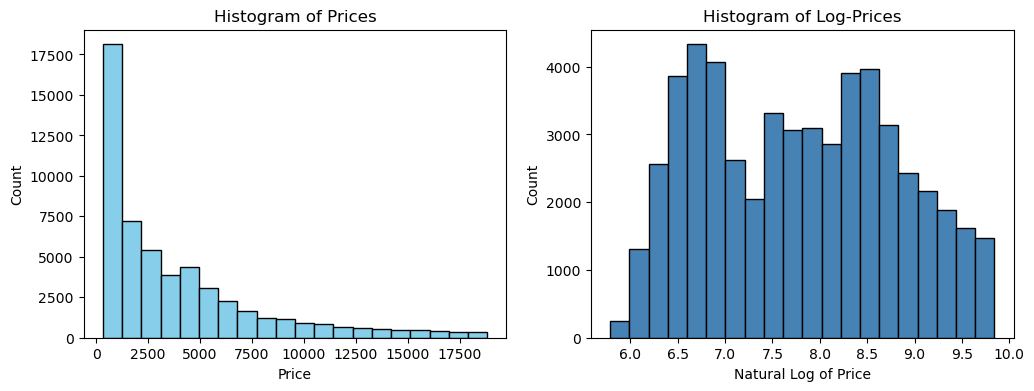

In [19]:
plt.figure(figsize=[12,4])
plt.subplot(1, 2, 1)
plt.hist(diamonds['price'], bins=20, edgecolor='black', color='skyblue')
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Histogram of Prices')

plt.subplot(1, 2, 2)
plt.hist(diamonds['ln_price'], bins=20, edgecolor='black', color='steelblue')
plt.xlabel('Natural Log of Price')
plt.ylabel('Count')
plt.title('Histogram of Log-Prices')

plt.show()

We will now use histograms to explore the distribution of the carat sizes, and the
log of the carat sizes. 

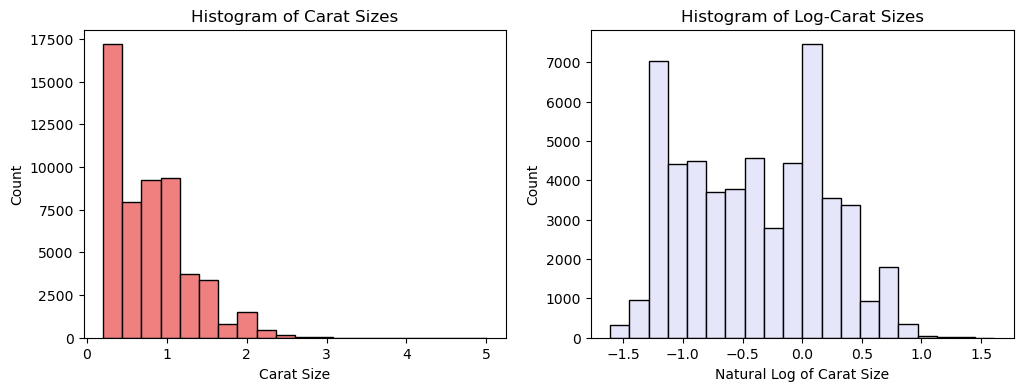

In [20]:
plt.figure(figsize=[12,4])

plt.subplot(1, 2, 1)
plt.hist(diamonds['carat'], bins=20, edgecolor='black', color='lightcoral')
plt.xlabel('Carat Size')
plt.ylabel('Count')
plt.title('Histogram of Carat Sizes')

plt.subplot(1, 2, 2)
plt.hist(diamonds['ln_carat'], bins=20, edgecolor='black', color='lavender')
plt.xlabel('Natural Log of Carat Size')
plt.ylabel('Count')
plt.title('Histogram of Log-Carat Sizes')

plt.show()

## Part 7: Scatterplot of Transformed Variables

In this part, we will create a scatterplot of ln_price against ln_carat, with points colored according to their clarity levels.


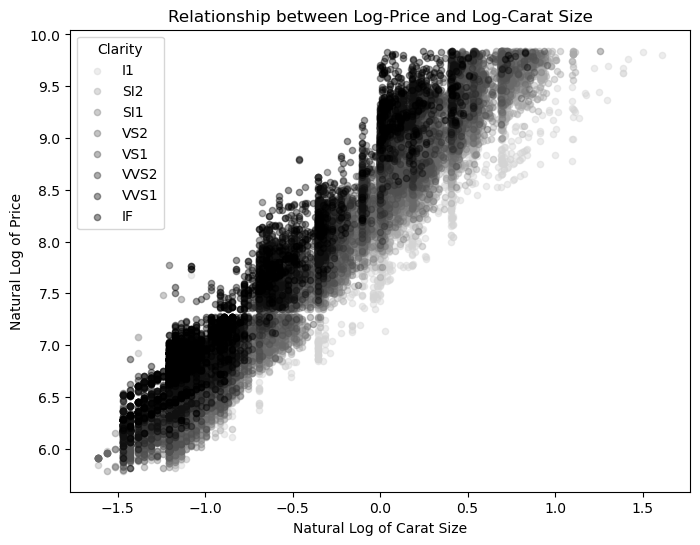

In [21]:
plt.figure(figsize=[8,6])
for clarity, color in zip(clarity_levels, clarity_pal):
    subset = diamonds[diamonds['clarity'] == clarity]
    plt.scatter(subset['ln_carat'], subset['ln_price'], s=20, c=color, alpha=0.4, label=clarity)
plt.xlabel('Natural Log of Carat Size')
plt.ylabel('Natural Log of Price')
plt.title('Relationship between Log-Price and Log-Carat Size')
plt.legend(title='Clarity')
plt.show()


## Part 8: Grouping by Cut

In this part, we will calculate the mean price and carat size for each level of the variable cut.

In [22]:
gb_cut = diamonds[['cut', 'price', 'carat']]
gb_cut_mean = gb_cut.groupby('cut').mean()
gb_cut_mean

,price,carat
cut,,
Fair,4358.757764,1.046137
Good,3928.864452,0.849185
Very Good,3981.759891,0.806381
Premium,4584.257704,0.891955
Ideal,3457.541970,0.702837


We will now use bar charts to graphically display the information from the grouped DataFrame above. 

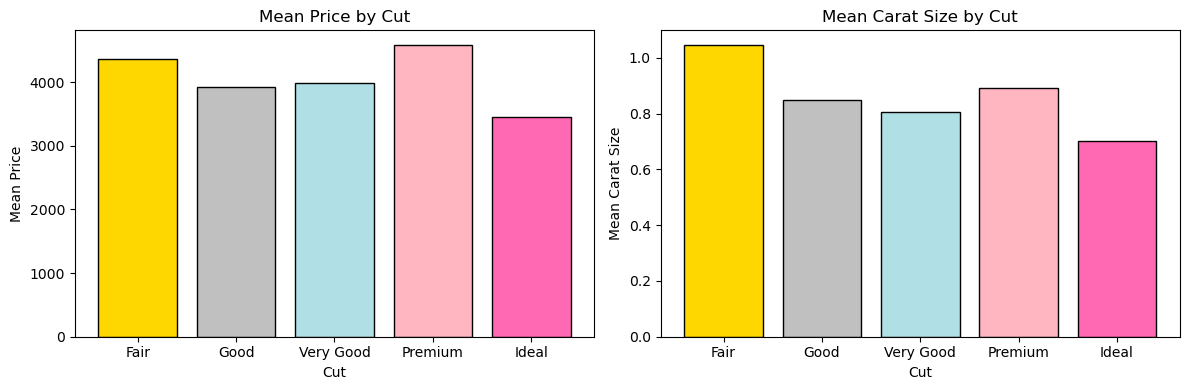

In [23]:
plt.figure(figsize=[12,4])
plt.subplot(1, 2, 1)
plt.bar(gb_cut_mean.index, gb_cut_mean['price'], color=cut_pal, edgecolor='black')
plt.xlabel('Cut')
plt.ylabel('Mean Price')
plt.title('Mean Price by Cut')
plt.subplot(1, 2, 2)
plt.bar(gb_cut_mean.index, gb_cut_mean['carat'], color=cut_pal, edgecolor='black')
plt.xlabel('Cut')
plt.ylabel('Mean Carat Size')
plt.title('Mean Carat Size by Cut')
plt.tight_layout()
plt.show()


## Part 9: Grouping by Color

In this part, we will calculate the mean price and carat size for each level of the variable color.

In [24]:
gb_color = diamonds[['color', 'price', 'carat']].groupby('color').mean()
gb_color


,price,carat
color,,
J,5323.818020,1.162137
I,5091.874954,1.026927
H,4486.669196,0.911799
G,3999.135671,0.771190
F,3724.886397,0.736538
E,3076.752475,0.657867
D,3169.954096,0.657795


We will now use bar charts to graphically display the information from the
DataFrame above. 

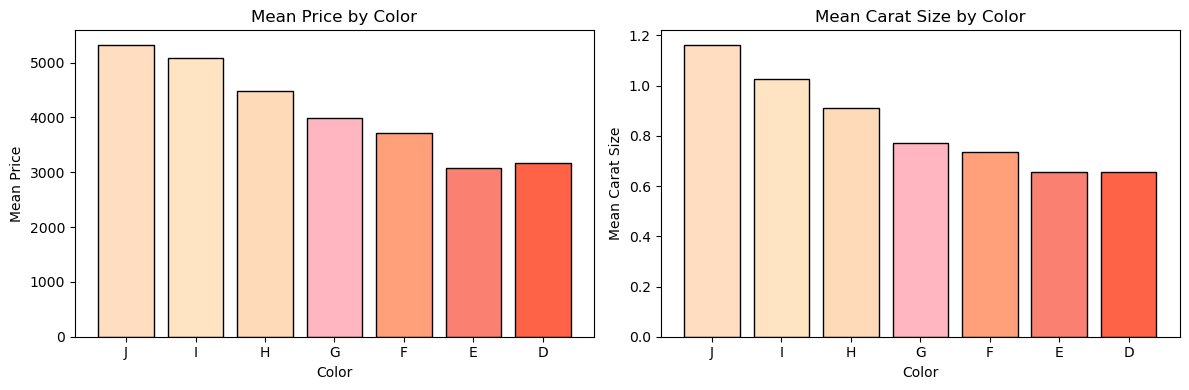

In [25]:
plt.figure(figsize=[12,4])
plt.subplot(1, 2, 1)
plt.bar(gb_color.index, gb_color['price'], color=color_pal, edgecolor='black')
plt.xlabel('Color')
plt.ylabel('Mean Price')
plt.title('Mean Price by Color')

plt.subplot(1, 2, 2)
plt.bar(gb_color.index, gb_color['carat'], color=color_pal, edgecolor='black')
plt.xlabel('Color')
plt.ylabel('Mean Carat Size')
plt.title('Mean Carat Size by Color')

plt.tight_layout()
plt.show()


## Part 10: Grouping by Clarity

In this part, we will calculate the mean price and carat size for each level of the variable clarity.

In [26]:
gb_clarity = diamonds[['clarity', 'price', 'carat']].groupby('clarity').mean()
gb_clarity


,price,carat
clarity,,
I1,3924.168691,1.283846
SI2,5063.028606,1.077648
SI1,3996.001148,0.850482
VS2,3924.989395,0.763935
VS1,3839.455391,0.727158
VVS2,3283.737071,0.596202
VVS1,2523.114637,0.503321
IF,2864.839106,0.505123


We will now use bar charts to graphically display the information from the
DataFrame above.

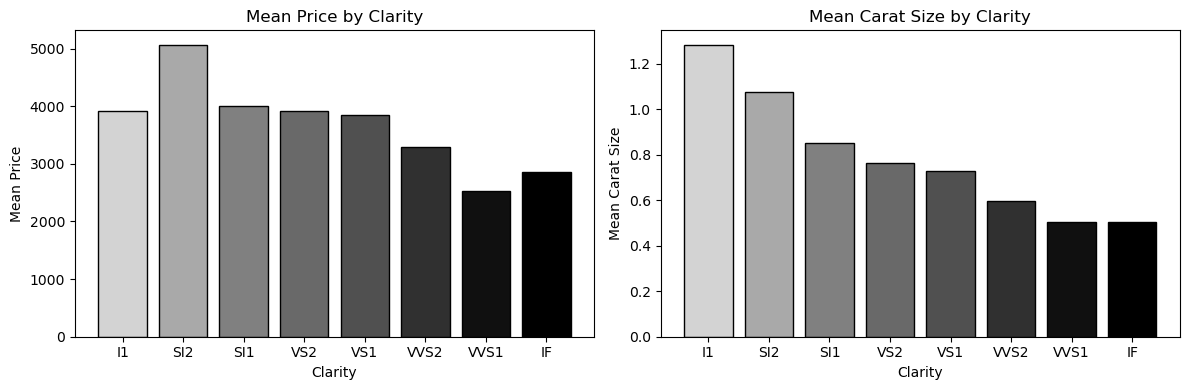

In [27]:
plt.figure(figsize=[12,4])
plt.subplot(1, 2, 1)
plt.bar(gb_clarity.index, gb_clarity['price'], color=clarity_pal, edgecolor='black')
plt.xlabel('Clarity')
plt.ylabel('Mean Price')
plt.title('Mean Price by Clarity')

plt.subplot(1, 2, 2)
plt.bar(gb_clarity.index, gb_clarity['carat'], color=clarity_pal, edgecolor='black')
plt.xlabel('Clarity')
plt.ylabel('Mean Carat Size')
plt.title('Mean Carat Size by Clarity')
plt.tight_layout()
plt.show()
